# Projet Final — Pipeline d'Analyse de Marchés Financiers

Ce notebook combine l'ensemble des TPs (TP1 à TP8) pour construire un pipeline d'analyse quotidienne des marchés d'actions.  
Il couvre :
- **TP1** : Scraping des ratios financiers et historiques de prix
- **TP2** : Clustering (K-Means, Hierarchical, DBSCAN)
- **TP3** : Classification Buy/Hold/Sell
- **TP4** : Régression ML pour prédiction J+1
- **TP5** : Réseaux de neurones (MLP, RNN, LSTM)
- **TP6** : Scraping de news financières (NewsAPI)
- **TP7** : Fine-tuning BERT / FinBERT
- **TP8** : Analyse de sentiment & corrélation avec les prix
- **Agrégation** : Stratégie de recommandation combinée

---
## 0. Installation des dépendances

In [3]:
# Décommenter si nécessaire
# !pip install yfinance pandas numpy scikit-learn matplotlib scipy xgboost ta shap
# !pip install tensorflow transformers datasets torch requests pytz
# !pip install newsapi-python

---
## 0.1 Imports globaux

In [26]:
import os
import json
import glob
import warnings
import time
warnings.filterwarnings('ignore')

from datetime import datetime, timedelta
from collections import defaultdict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
from matplotlib.lines import Line2D

import yfinance as yf
import requests
import pytz

# ML
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
from sklearn.manifold import TSNE
from sklearn.metrics import (
    silhouette_score, classification_report, accuracy_score,
    mean_absolute_error, mean_squared_error, 
    precision_recall_fscore_support
)
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.neighbors import KNeighborsClassifier, KNeighborsRegressor
from sklearn.svm import SVC
from xgboost import XGBClassifier, XGBRegressor
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster
from scipy.spatial.distance import squareform, pdist, cdist
import ta
import shap

# Deep Learning
import tensorflow as tf
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense, SimpleRNN, LSTM, Dropout
from tensorflow.keras.optimizers import Adam

# NLP
import torch
from transformers import (
    AutoTokenizer, AutoModelForSequenceClassification,
    BertTokenizer, BertForSequenceClassification,
    Trainer, TrainingArguments
)
from datasets import load_dataset, concatenate_datasets, DatasetDict, ClassLabel

---
## 0.2 Configuration globale

In [28]:
# ─── Clé NewsAPI ────────────────────────────────────────────────────────────
# NEWS_API_KEY = "8df5fe70ce6c47f799dbb257de5c2821"   # Compte personnel
NEWS_API_KEY = "bf61d6587df8461391e36e1be75b158f" # Compte dauphine

# ─── Répertoires de sortie ───────────────────────────────────────────────────
os.makedirs("companies_historical_data", exist_ok=True)
os.makedirs("news_data", exist_ok=True)
os.makedirs("bert_results", exist_ok=True)

# ─── Univers d'entreprises ────────────────────────────────────────────────────
companies = {
    "Apple": "AAPL",
    "Microsoft": "MSFT",
    "Amazon": "AMZN",
    "Alphabet": "GOOGL",
    "Meta": "META",
    "Tesla": "TSLA",
    "NVIDIA": "NVDA",
    "Samsung": "005930.KS",
    "Tencent": "TCEHY",
    "Alibaba": "BABA",
    "IBM": "IBM",
    "Intel": "INTC",
    "Oracle": "ORCL",
    "Sony": "SONY",
    "Adobe": "ADBE",
    "Netflix": "NFLX",
    "AMD": "AMD",
    "Qualcomm": "QCOM",
    "Cisco": "CSCO",
    "JP Morgan": "JPM",
    "Goldman Sachs": "GS",
    "Visa": "V",
    "Johnson & Johnson": "JNJ",
    "Pfizer": "PFE",
    "ExxonMobil": "XOM",
    "ASML": "ASML.AS",
    "SAP": "SAP.DE",
    "Siemens": "SIE.DE",
    "Louis Vuitton (LVMH)": "MC.PA",
    "TotalEnergies": "TTE.PA",
    "Shell": "SHEL.L",
    "Baidu": "BIDU",
    "JD.com": "JD",
    "BYD": "BYDDY",
    "ICBC": "1398.HK",
    "Toyota": "TM",
    "SoftBank": "9984.T",
    "Nintendo": "NTDOY",
    "Hyundai": "HYMLF",
    "Reliance Industries": "RELIANCE.NS",
    "Tata Consultancy Services": "TCS.NS"
}

RATIOS = [
    "forwardPE", "beta", "priceToBook", "priceToSales",
    "dividendYield", "trailingEps", "debtToEquity",
    "currentRatio", "quickRatio", "returnOnEquity",
    "returnOnAssets", "operatingMargins", "profitMargins"
]

# Dates
END_DATE   = datetime.today().strftime('%Y-%m-%d')
START_DATE = (datetime.today() - timedelta(days=5*365)).strftime('%Y-%m-%d')

print(f"Période d'analyse : {START_DATE} → {END_DATE}")
print(f"Nombre d'entreprises : {len(companies)}")

Période d'analyse : 2021-05-11 → 2026-05-10
Nombre d'entreprises : 41


---
# TP1 — Scraping des données financières
## 1.1 Ratios financiers

In [9]:
def scrape_financial_ratios(companies: dict, ratios: list) -> pd.DataFrame:
    """Scrape les ratios financiers de chaque entreprise via yfinance."""
    data = {ratio: [] for ratio in ratios}
    index = []

    for company_name, symbol in companies.items():
        try:
            ticker = yf.Ticker(symbol)
            info   = ticker.info
            for ratio in ratios:
                data[ratio].append(info.get(ratio, np.nan))
            index.append(company_name)
            print(f"  ✔ {company_name}")
        except Exception as e:
            print(f"  ✘ {company_name} : {e}")

    df = pd.DataFrame(data, index=index)
    df.to_csv("financial_ratios.csv")
    print(f"\n✅ Ratios exportés → financial_ratios.csv ({df.shape})")
    return df

financial_ratios_df = scrape_financial_ratios(companies, RATIOS)
financial_ratios_df

  ✔ Apple
  ✔ Microsoft
  ✔ Amazon
  ✔ Alphabet
  ✔ Meta
  ✔ Tesla
  ✔ NVIDIA
  ✔ Samsung
  ✔ Tencent
  ✔ Alibaba
  ✔ IBM
  ✔ Intel
  ✔ Oracle
  ✔ Sony
  ✔ Adobe
  ✔ Netflix
  ✔ AMD
  ✔ Qualcomm
  ✔ Cisco
  ✔ JP Morgan
  ✔ Goldman Sachs
  ✔ Visa
  ✔ Johnson & Johnson
  ✔ Pfizer
  ✔ ExxonMobil
  ✔ ASML
  ✔ SAP
  ✔ Siemens
  ✔ Louis Vuitton (LVMH)
  ✔ TotalEnergies
  ✔ Shell
  ✔ Baidu
  ✔ JD.com
  ✔ BYD
  ✔ ICBC
  ✔ Toyota
  ✔ SoftBank
  ✔ Nintendo


HTTP Error 404: {"quoteSummary":{"result":null,"error":{"code":"Not Found","description":"Quote not found for symbol: HYMLF"}}}


  ✔ Hyundai
  ✔ Reliance Industries
  ✔ Tata Consultancy Services

✅ Ratios exportés → financial_ratios.csv ((41, 13))


,forwardPE,beta,priceToBook,priceToSales,dividendYield,trailingEps,debtToEquity,currentRatio,quickRatio,returnOnEquity,returnOnAssets,operatingMargins,profitMargins
Apple,30.444586,1.065,48.522007,NaN,0.38,8.25,79.548,1.070,0.906,1.41471,0.26229,0.32275,0.27152
Microsoft,22.014730,1.093,8.098166,NaN,0.88,16.81,30.271,1.283,1.142,0.34014,0.14814,0.46326,0.39342
Amazon,27.623075,1.468,6.638357,NaN,NaN,8.36,53.300,1.177,0.974,0.24285,0.06845,0.13140,0.12224
Alphabet,27.404165,1.267,11.538731,NaN,0.22,13.10,20.026,1.922,1.707,0.38885,0.14641,0.36121,0.37919
Meta,17.214964,1.243,7.254708,NaN,0.34,27.52,35.608,2.348,2.110,0.32930,0.16395,0.40617,0.32837
Tesla,161.740370,1.793,18.727228,NaN,NaN,1.08,18.738,2.043,1.430,0.04901,0.02233,0.04203,0.03946
NVIDIA,18.817211,2.244,32.677690,NaN,0.02,4.90,7.255,3.905,3.141,1.01485,0.51188,0.65024,0.55603
Samsung,5.389976,1.327,NaN,NaN,0.56,NaN,5.782,9.273,7.397,0.18854,0.10231,0.42718,0.21462
Tencent,12.125751,0.753,3.253679,NaN,1.11,3.54,32.746,1.443,1.242,0.20027,0.08038,0.33135,0.29909
Alibaba,19.337862,0.494,2.172208,NaN,0.74,5.67,25.908,1.331,0.735,0.08233,0.03134,0.07078,0.08912


In [10]:
def clean_financial_ratios(df: pd.DataFrame) -> pd.DataFrame:
    """Nettoie les données de ratios financiers."""
    df = df.copy()
    df = df.dropna(axis=1, how='all')
    df = df.dropna(axis=0, how='all')
    df.to_csv("financial_ratios.csv")
    return df

financial_ratios_df = clean_financial_ratios(financial_ratios_df)
financial_ratios_df

,forwardPE,beta,priceToBook,dividendYield,trailingEps,debtToEquity,currentRatio,quickRatio,returnOnEquity,returnOnAssets,operatingMargins,profitMargins
Apple,30.444586,1.065,48.522007,0.38,8.25,79.548,1.070,0.906,1.41471,0.26229,0.32275,0.27152
Microsoft,22.014730,1.093,8.098166,0.88,16.81,30.271,1.283,1.142,0.34014,0.14814,0.46326,0.39342
Amazon,27.623075,1.468,6.638357,NaN,8.36,53.300,1.177,0.974,0.24285,0.06845,0.13140,0.12224
Alphabet,27.404165,1.267,11.538731,0.22,13.10,20.026,1.922,1.707,0.38885,0.14641,0.36121,0.37919
Meta,17.214964,1.243,7.254708,0.34,27.52,35.608,2.348,2.110,0.32930,0.16395,0.40617,0.32837
Tesla,161.740370,1.793,18.727228,NaN,1.08,18.738,2.043,1.430,0.04901,0.02233,0.04203,0.03946
NVIDIA,18.817211,2.244,32.677690,0.02,4.90,7.255,3.905,3.141,1.01485,0.51188,0.65024,0.55603
Samsung,5.389976,1.327,NaN,0.56,NaN,5.782,9.273,7.397,0.18854,0.10231,0.42718,0.21462
Tencent,12.125751,0.753,3.253679,1.11,3.54,32.746,1.443,1.242,0.20027,0.08038,0.33135,0.29909
Alibaba,19.337862,0.494,2.172208,0.74,5.67,25.908,1.331,0.735,0.08233,0.03134,0.07078,0.08912


## 1.2 Historique des prix (5 ans)

In [11]:
def scrape_stock_history(companies: dict, start: str, end: str) -> dict:
    """Télécharge 5 ans d'historique de prix et calcule les rendements.
    Sauvegarde un CSV par entreprise dans 'companies_historical_data/'.
    """
    all_data = {}

    for company_name, symbol in companies.items():
        try:
            raw = yf.download(symbol, start=start, end=end, progress=False)
            if raw.empty:
                print(f"  ✘ {company_name} : données vides")
                continue

            df = raw[["Close"]].copy()
            df.columns = ["Close"]
            df["Next Day Close"] = df["Close"].shift(-1) # Pour le jour n on veut les données du jour n+1 donc -1
            df["Daily Return"]   = (df["Next Day Close"] - df["Close"]) / df["Close"]
            df.dropna(inplace=True)

            path = f"companies_historical_data/{company_name.replace('/', '_')}.csv"
            df.to_csv(path)
            all_data[company_name] = df
            print(f"  ✔ {company_name} → {path}")
        except Exception as e:
            print(f"  ✘ {company_name} : {e}")

    print(f"\n✅ {len(all_data)} entreprises téléchargées")
    return all_data


historical_data = scrape_stock_history(companies, START_DATE, END_DATE)

  ✔ Apple → companies_historical_data/Apple.csv
  ✔ Microsoft → companies_historical_data/Microsoft.csv
  ✔ Amazon → companies_historical_data/Amazon.csv
  ✔ Alphabet → companies_historical_data/Alphabet.csv
  ✔ Meta → companies_historical_data/Meta.csv
  ✔ Tesla → companies_historical_data/Tesla.csv
  ✔ NVIDIA → companies_historical_data/NVIDIA.csv
  ✔ Samsung → companies_historical_data/Samsung.csv
  ✔ Tencent → companies_historical_data/Tencent.csv
  ✔ Alibaba → companies_historical_data/Alibaba.csv
  ✔ IBM → companies_historical_data/IBM.csv
  ✔ Intel → companies_historical_data/Intel.csv
  ✔ Oracle → companies_historical_data/Oracle.csv
  ✔ Sony → companies_historical_data/Sony.csv
  ✔ Adobe → companies_historical_data/Adobe.csv
  ✔ Netflix → companies_historical_data/Netflix.csv
  ✔ AMD → companies_historical_data/AMD.csv
  ✔ Qualcomm → companies_historical_data/Qualcomm.csv
  ✔ Cisco → companies_historical_data/Cisco.csv
  ✔ JP Morgan → companies_historical_data/JP Morgan.csv
  

$HYMLF: possibly delisted; no price data found  (1d 2021-05-08 -> 2026-05-07) (Yahoo error = "No data found, symbol may be delisted")

1 Failed download:
['HYMLF']: possibly delisted; no price data found  (1d 2021-05-08 -> 2026-05-07) (Yahoo error = "No data found, symbol may be delisted")


  ✘ Hyundai : données vides
  ✔ Reliance Industries → companies_historical_data/Reliance Industries.csv
  ✔ Tata Consultancy Services → companies_historical_data/Tata Consultancy Services.csv

✅ 40 entreprises téléchargées


---
# TP2 — Clustering
## 2.1 Pré-processing des données de clustering

In [12]:
FINANCIAL_FEATURES = ["forwardPE", "beta", "priceToBook",
                      "returnOnEquity", "profitMargins", "operatingMargins"]

RISK_FEATURES = ["beta", "debtToEquity", "currentRatio",
                 "quickRatio", "returnOnAssets", "dividendYield"]


def preprocess_for_financial_clustering(df: pd.DataFrame,
                                        features: list) -> tuple:
    """Sélection, nettoyage et standardisation des features."""
    subset = df[features].dropna()
    scaler = StandardScaler()
    scaled = scaler.fit_transform(subset)
    return scaled, subset.index.tolist()


financial_scaled, financial_labels = preprocess_for_financial_clustering(
    financial_ratios_df, FINANCIAL_FEATURES
)
risk_scaled, risk_labels = preprocess_for_financial_clustering(
    financial_ratios_df, RISK_FEATURES
)

print(f"Données financières : {financial_scaled.shape}")
print(f"Données de risque   : {risk_scaled.shape}")

Données financières : (39, 6)
Données de risque   : (30, 6)


## 2.2 Méthode du coude (KMeans)

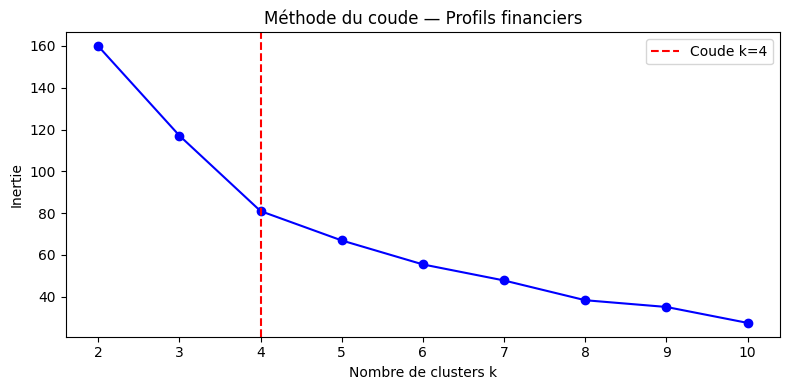

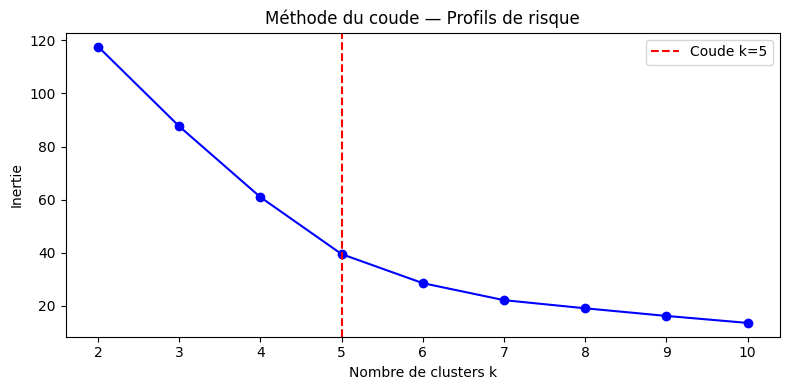

k optimal financier : 4 | k optimal risque : 5


In [13]:
def elbow_method(data: np.ndarray, k_max: int = 10, title: str = "") -> int:
    """Trace la courbe d'inertie et retourne le k optimal (coude)."""
    inertias = []
    ks = range(2, k_max + 1)
    for k in ks:
        km = KMeans(n_clusters=k, random_state=42, n_init=10)
        km.fit(data)
        inertias.append(km.inertia_)

    # Détection automatique du coude (différence de pente)
    diffs = np.diff(inertias)
    diffs2 = np.diff(diffs)
    elbow_k = int(ks[np.argmax(diffs2) + 1])

    plt.figure(figsize=(8, 4))
    plt.plot(list(ks), inertias, 'bo-')
    plt.axvline(x=elbow_k, color='red', linestyle='--', label=f'Coude k={elbow_k}')
    plt.xlabel('Nombre de clusters k')
    plt.ylabel('Inertie')
    plt.title(f'Méthode du coude {title}')
    plt.legend()
    plt.tight_layout()
    plt.show()
    return elbow_k


k_financial = elbow_method(financial_scaled, title="— Profils financiers")
k_risk      = elbow_method(risk_scaled,      title="— Profils de risque")
print(f"k optimal financier : {k_financial} | k optimal risque : {k_risk}")

## 2.3 K-Means Clustering + visualisation t-SNE


=== KMeans (Profils financiers) — k=4 ===
cluster
0     2
1    20
2     2
3    15
Name: count, dtype: int64


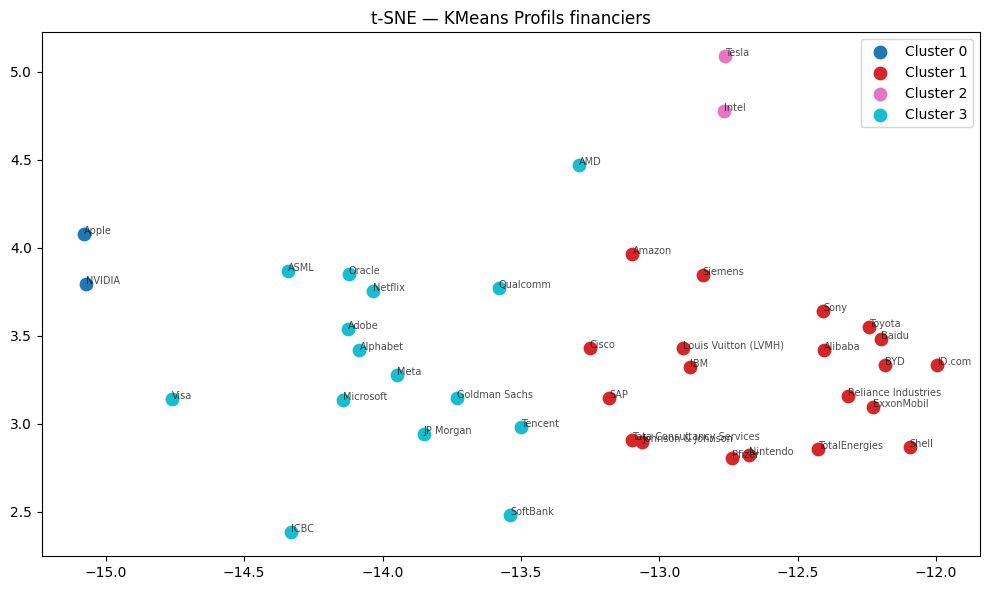


=== KMeans (Profils de risque) — k=5 ===
cluster
0    17
1     1
2     9
3     1
4     2
Name: count, dtype: int64


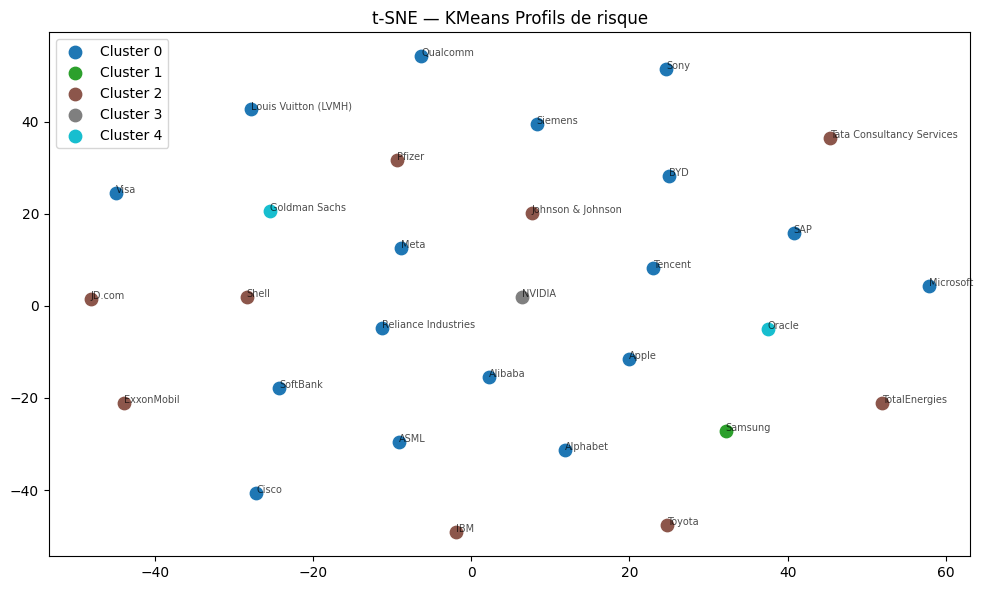

In [14]:
def do_kmeans_clustering(data: np.ndarray, labels: list,
                         k: int, title: str = "") -> pd.DataFrame:
    """Applique KMeans, affiche les statistiques et la projection t-SNE."""
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    cluster_labels = km.fit_predict(data)

    result_df = pd.DataFrame(data, index=labels)
    result_df["cluster"] = cluster_labels

    print(f"\n=== KMeans ({title}) — k={k} ===")
    print(result_df["cluster"].value_counts().sort_index())

    # t-SNE
    perp = min(30, len(data) - 1)
    tsne = TSNE(n_components=2, random_state=42, perplexity=perp)
    tsne_coords = tsne.fit_transform(data)

    cmap = plt.cm.get_cmap('tab10', k)
    plt.figure(figsize=(10, 6))
    for c in range(k):
        mask = cluster_labels == c
        plt.scatter(tsne_coords[mask, 0], tsne_coords[mask, 1],
                    color=cmap(c), label=f"Cluster {c}", s=80)
        for i, txt in enumerate(np.array(labels)[mask]):
            plt.annotate(txt, (tsne_coords[mask][i, 0], tsne_coords[mask][i, 1]),
                         fontsize=7, alpha=0.7)
    plt.title(f't-SNE — KMeans {title}')
    plt.legend()
    plt.tight_layout()
    plt.show()
    return result_df


kmeans_financial_df = do_kmeans_clustering(
    financial_scaled, financial_labels, k_financial, "Profils financiers")

kmeans_risk_df = do_kmeans_clustering(
    risk_scaled, risk_labels, k_risk, "Profils de risque")

## 2.4 Clustering Hiérarchique + Dendrogramme

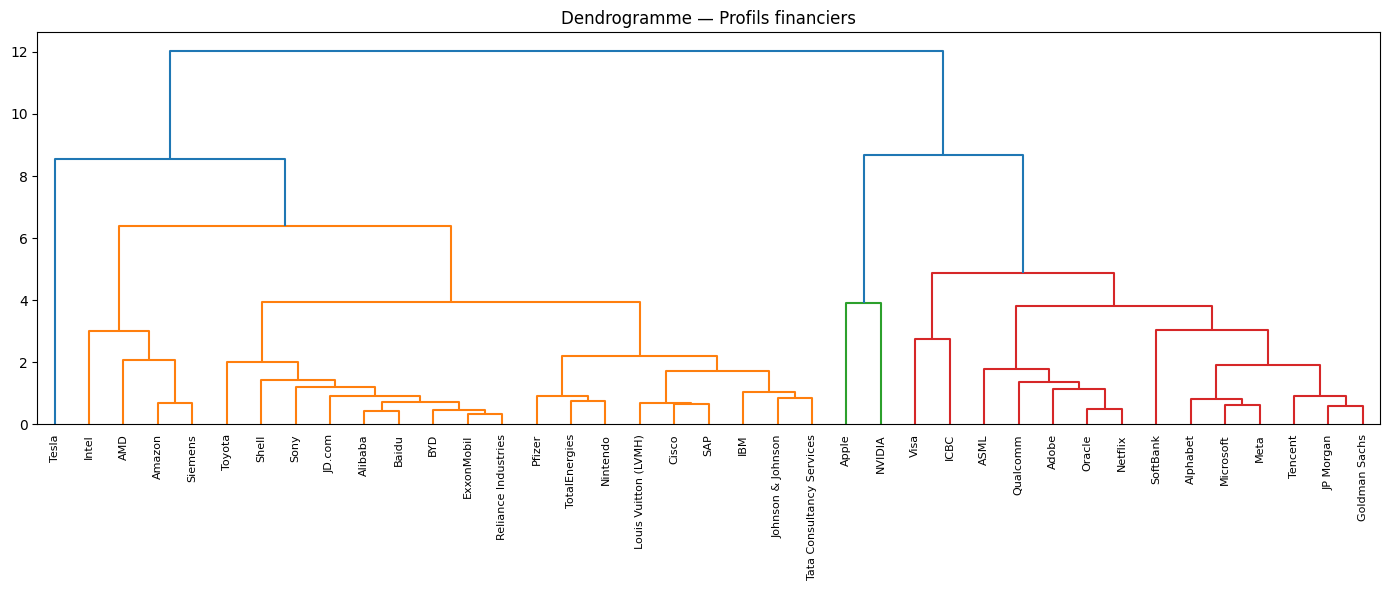


=== Hierarchical Clustering (Profils financiers) — k=4 ===
cluster
0    22
1    14
2     2
3     1
Name: count, dtype: int64


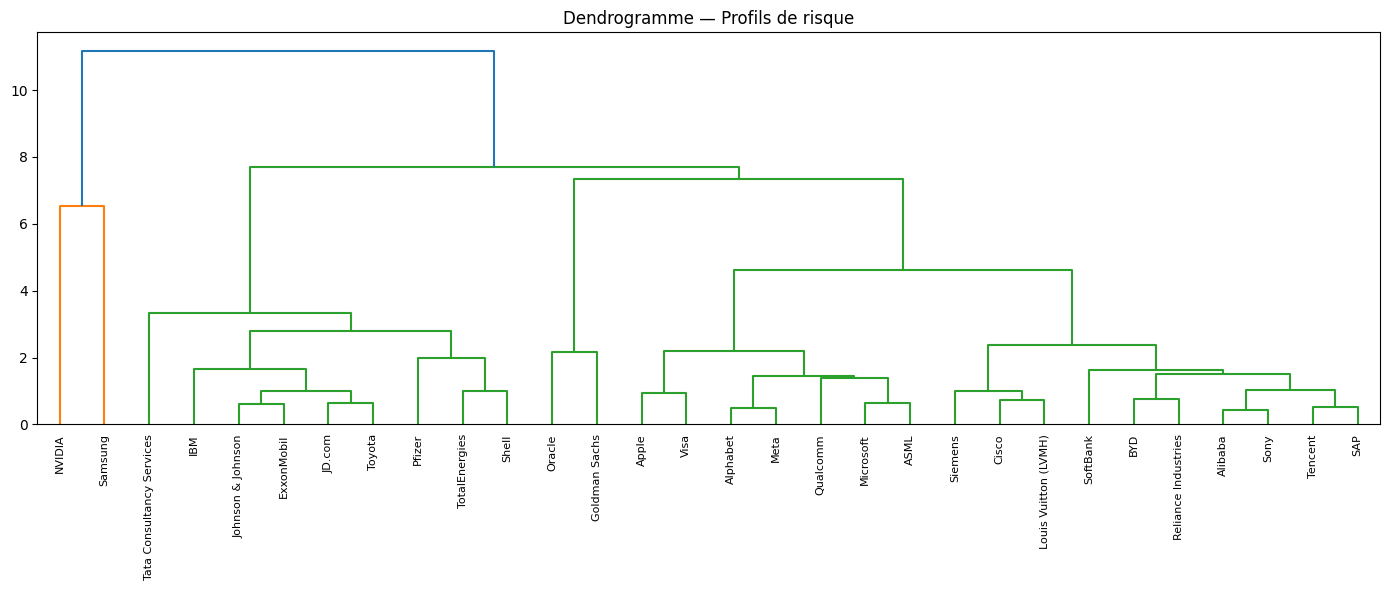


=== Hierarchical Clustering (Profils de risque) — k=5 ===
cluster
0    17
1     2
2     9
3     1
4     1
Name: count, dtype: int64


In [15]:
def plot_dendrogram(data: np.ndarray, labels: list, title: str = ""):
    """Trace le dendrogramme du clustering hiérarchique."""
    linked = linkage(data, method='ward')
    plt.figure(figsize=(14, 6))
    dendrogram(linked, labels=labels, leaf_rotation=90, leaf_font_size=8)
    plt.title(f'Dendrogramme — {title}')
    plt.tight_layout()
    plt.show()
    return linked


def do_hierarchical_clustering(data: np.ndarray, labels: list,
                               n_clusters: int, title: str = "") -> pd.DataFrame:
    """Clustering hiérarchique AgglomerativeClustering + dendrogramme."""
    plot_dendrogram(data, labels, title)

    agg = AgglomerativeClustering(n_clusters=n_clusters, linkage='ward')
    cluster_labels = agg.fit_predict(data)

    result_df = pd.DataFrame(data, index=labels)
    result_df["cluster"] = cluster_labels

    print(f"\n=== Hierarchical Clustering ({title}) — k={n_clusters} ===")
    print(result_df["cluster"].value_counts().sort_index())
    return result_df


hier_financial_df = do_hierarchical_clustering(
    financial_scaled, financial_labels, k_financial, "Profils financiers")

hier_risk_df = do_hierarchical_clustering(
    risk_scaled, risk_labels, k_risk, "Profils de risque")

## 2.5 Clustering sur les corrélations de rendements journaliers

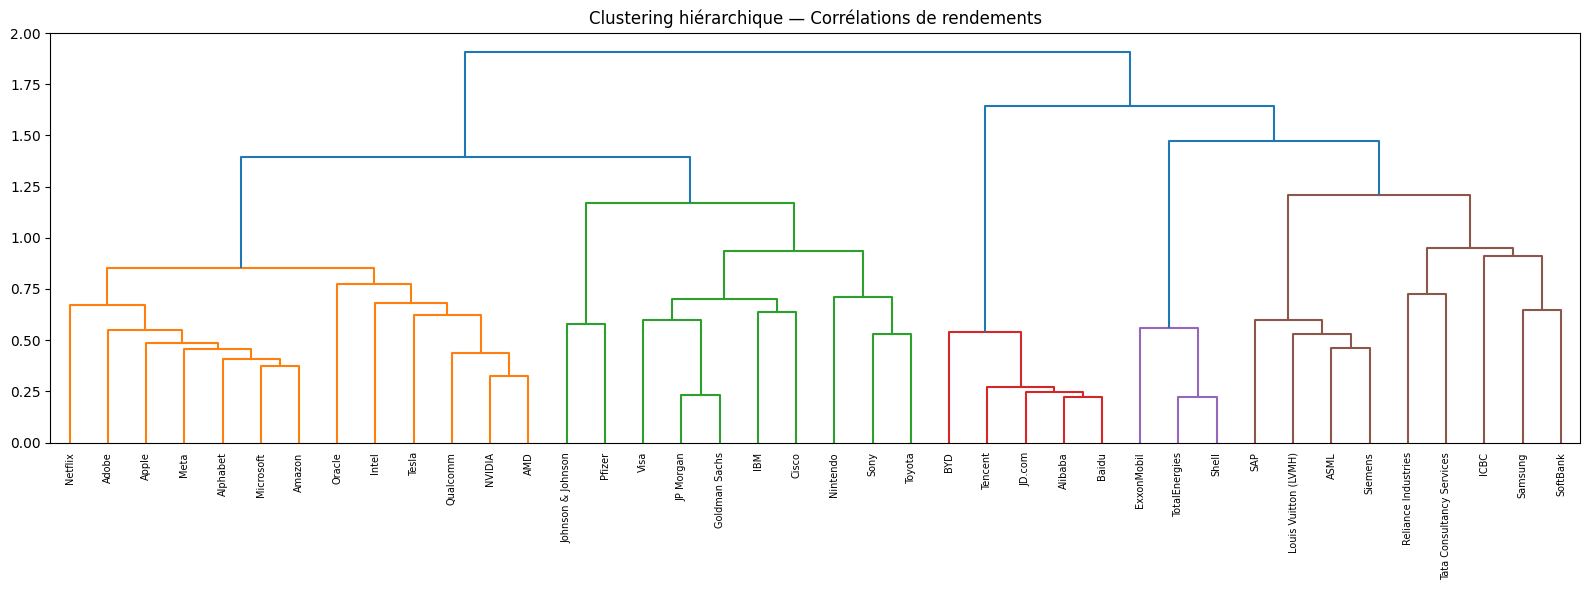

cluster
1    13
2    10
3     5
4     3
5     9
Name: count, dtype: int64


In [16]:
def prepare_returns_matrix(historical_data: dict) -> pd.DataFrame:
    """Construit la matrice des rendements journaliers (entreprises × dates)."""
    returns_dict = {}
    for company_name, df in historical_data.items():
        if "Daily Return" in df.columns:
            returns_dict[company_name] = df["Daily Return"]

    returns_df = pd.DataFrame(returns_dict)
    returns_df.fillna(returns_df.mean(), inplace=True)
    return returns_df


def cluster_by_returns_correlation(returns_df: pd.DataFrame, n_clusters: int = 5):
    """Clustering hiérarchique sur la matrice de corrélation des rendements."""
    corr_matrix = returns_df.corr()
    distance_matrix = 1 - corr_matrix
    condensed = squareform(distance_matrix.values, checks=False)

    labels = corr_matrix.columns.tolist()
    linked = linkage(condensed, method='ward')

    plt.figure(figsize=(16, 6))
    dendrogram(linked, labels=labels, leaf_rotation=90, leaf_font_size=7)
    plt.title("Clustering hiérarchique — Corrélations de rendements")
    plt.tight_layout()
    plt.show()

    cluster_assignments = fcluster(linked, t=n_clusters, criterion='maxclust')
    return pd.Series(cluster_assignments, index=labels, name="cluster")


returns_df = prepare_returns_matrix(historical_data)
returns_clusters = cluster_by_returns_correlation(returns_df, n_clusters=5)
print(returns_clusters.value_counts().sort_index())

## 2.6 DBSCAN + tableau de comparaison des Silhouette Scores

In [17]:
def do_dbscan_clustering(data: np.ndarray, eps: float = 0.5,
                         min_samples: int = 2) -> np.ndarray:
    """Applique DBSCAN et retourne les labels de clusters."""
    db = DBSCAN(eps=eps, min_samples=min_samples)
    return db.fit_predict(data)


def compare_clustering_algorithms(datasets: dict) -> pd.DataFrame:
    """Compare KMeans, Hierarchical et DBSCAN sur chaque type de données."""
    results = []
    for data_name, (data, n_clust) in datasets.items():
        # KMeans
        km_labels = KMeans(n_clusters=n_clust, random_state=42, n_init=10).fit_predict(data)
        # Hierarchical
        ag_labels = AgglomerativeClustering(n_clusters=n_clust).fit_predict(data)
        # DBSCAN
        db_labels = do_dbscan_clustering(data)

        for algo, labs in [("KMeans", km_labels), ("Hierarchical", ag_labels), ("DBSCAN", db_labels)]:
            unique = set(labs) - {-1}
            if len(unique) >= 2:
                score = silhouette_score(data, labs)
            else:
                score = np.nan
            results.append({"Données": data_name, "Algorithme": algo, "Silhouette": round(score, 4) if not np.isnan(score) else "N/A"})

    return pd.DataFrame(results)


# Matrice de corrélation pour DBSCAN
corr_scaled = returns_df.corr().values

clustering_datasets = {
    "Finance":    (financial_scaled, k_financial),
    "Risque":     (risk_scaled,      k_risk),
    "Rendements": (corr_scaled,      5)
}

silhouette_table = compare_clustering_algorithms(clustering_datasets)
print("\n=== Tableau comparatif des Silhouette Scores ===")
silhouette_table


=== Tableau comparatif des Silhouette Scores ===


,Données,Algorithme,Silhouette
0,Finance,KMeans,0.3621
1,Finance,Hierarchical,0.3324
2,Finance,DBSCAN,-0.1506
3,Risque,KMeans,0.3366
4,Risque,Hierarchical,0.3366
5,Risque,DBSCAN,-0.2130
6,Rendements,KMeans,0.2888
7,Rendements,Hierarchical,0.2509
8,Rendements,DBSCAN,0.0436


---
# TP3 — Classification Buy / Hold / Sell
## 3.1 Création des labels

In [12]:
def create_classification_labels(df: pd.DataFrame) -> pd.DataFrame:
    """Crée les labels buy/hold/sell à partir du rendement sur 20 jours."""
    df = df[["Close"]].copy()
    df["Close Horizon"] = df["Close"].shift(-20)
    df["horizon_return"] = (df["Close Horizon"] - df["Close"]) / df["Close"]
    df["Label"] = df["horizon_return"].apply(
        lambda r: 2 if r > 0.05 else (0 if r < -0.05 else 1)
    )
    return df.dropna()


def add_technical_indicators(df: pd.DataFrame) -> pd.DataFrame:
    """Ajoute les indicateurs techniques via la librairie ta."""
    c = df["Close"]
    df["SMA_20"]          = ta.trend.sma_indicator(c, window=20)
    df["EMA_20"]          = ta.trend.ema_indicator(c, window=20)
    df["RSI_14"]          = ta.momentum.rsi(c, window=14)
    macd                  = ta.trend.MACD(c)
    df["MACD"]            = macd.macd()
    df["MACD_Signal"]     = macd.macd_signal()
    bb                    = ta.volatility.BollingerBands(c, window=20)
    df["Bollinger_High"]  = bb.bollinger_hband()
    df["Bollinger_Low"]   = bb.bollinger_lband()
    df["Rolling_Volatility"] = c.rolling(20).std()
    df["ROC_10"]          = ta.momentum.roc(c, window=10)
    return df


def build_classification_dataset(historical_data: dict) -> tuple:
    """Construit le dataset de classification (toutes entreprises concaténées)."""
    all_frames = []
    for company_name, df in historical_data.items():
        try:
            labeled   = create_classification_labels(df)
            with_tech = add_technical_indicators(labeled)
            with_tech.dropna(inplace=True)
            all_frames.append(with_tech)
        except Exception as e:
            print(f"  ✘ {company_name}: {e}")

    full_df = pd.concat(all_frames)

    drop_cols = [c for c in ["Label", "Close Horizon", "horizon_return",
                              "Next Day Close", "Daily Return"] if c in full_df.columns]
    X = full_df.drop(columns=drop_cols)
    y = full_df["Label"]

    scaler   = StandardScaler()
    X_scaled = scaler.fit_transform(X)

    X_train, X_test, y_train, y_test = train_test_split(
        X_scaled, y, test_size=0.2, random_state=42, stratify=y
    )
    print(f"Dataset : {full_df.shape} | Train : {X_train.shape} | Test : {X_test.shape}")
    return X_train, X_test, y_train, y_test, X


X_train_cls, X_test_cls, y_train_cls, y_test_cls, X_cls = build_classification_dataset(historical_data)

Dataset : (47981, 13) | Train : (38384, 10) | Test : (9597, 10)


## 3.2 Algorithmes de classification

In [13]:
def train_classifier(model, param_grid: dict, X_train, y_train, X_test, y_test,
                     model_name: str, feature_names=None) -> dict:
    """Gridsearch + évaluation d'un classifieur."""
    grid = GridSearchCV(model, param_grid, cv=3, scoring='accuracy', n_jobs=-1)
    grid.fit(X_train, y_train)
    best_model = grid.best_estimator_
    y_pred = best_model.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    print(f"\n{'='*50}")
    print(f"  {model_name} — Accuracy : {acc:.4f}")
    print(f"  Meilleurs hyperparamètres : {grid.best_params_}")
    print(classification_report(y_test, y_pred,
                                 target_names=["Sell", "Hold", "Buy"]))
    return {"model": best_model, "accuracy": acc, "name": model_name}


# XGBoost
xgb_cls_result = train_classifier(
    XGBClassifier(use_label_encoder=False, eval_metric='mlogloss', random_state=42),
    {"n_estimators": [100, 200], "max_depth": [3, 5], "learning_rate": [0.05, 0.1]},
    X_train_cls, y_train_cls, X_test_cls, y_test_cls, "XGBoost"
)

# Random Forest
rf_cls_result = train_classifier(
    RandomForestClassifier(random_state=42),
    {"n_estimators": [100, 200], "max_depth": [None, 10]},
    X_train_cls, y_train_cls, X_test_cls, y_test_cls, "Random Forest"
)

# KNN
knn_cls_result = train_classifier(
    KNeighborsClassifier(),
    {"n_neighbors": [5, 10, 15]},
    X_train_cls, y_train_cls, X_test_cls, y_test_cls, "KNN"
)

# Régression Logistique
lr_cls_result = train_classifier(
    LogisticRegression(max_iter=1000, random_state=42),
    {"C": [0.1, 1, 10]},
    X_train_cls, y_train_cls, X_test_cls, y_test_cls, "Logistic Regression"
)

# SVM
svm_cls_result = train_classifier(
    SVC(random_state=42),
    {"C": [0.1, 1], "kernel": ["rbf", "linear"]},
    X_train_cls, y_train_cls, X_test_cls, y_test_cls, "SVM"
)


  XGBoost — Accuracy : 0.5387
  Meilleurs hyperparamètres : {'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 200}
              precision    recall  f1-score   support

        Sell       0.58      0.27      0.37      2284
        Hold       0.53      0.84      0.65      4396
         Buy       0.56      0.29      0.38      2917

    accuracy                           0.54      9597
   macro avg       0.56      0.47      0.47      9597
weighted avg       0.55      0.54      0.50      9597


  Random Forest — Accuracy : 0.7607
  Meilleurs hyperparamètres : {'max_depth': None, 'n_estimators': 200}
              precision    recall  f1-score   support

        Sell       0.80      0.66      0.72      2284
        Hold       0.74      0.83      0.78      4396
         Buy       0.77      0.73      0.75      2917

    accuracy                           0.76      9597
   macro avg       0.77      0.74      0.75      9597
weighted avg       0.76      0.76      0.76      9597


  KNN — 

In [14]:
# SHAP — Explication du modèle XGBoost
try:
    explainer    = shap.TreeExplainer(xgb_cls_result["model"])
    shap_values  = explainer.shap_values(X_test_cls)
    print("SHAP — Importance pour 'Buy' (classe 2) :")
    shap.summary_plot(shap_values[:, :, 2], X_test_cls, feature_names=X_cls.columns)
    print("SHAP — Importance pour 'Sell' (classe 0) :")
    shap.summary_plot(shap_values[:, :, 0], X_test_cls, feature_names=X_cls.columns)
except Exception as e:
    print(f"SHAP non disponible : {e}")

# Tableau récapitulatif
cls_perf_df = pd.DataFrame([
    {"Modèle": r["name"], "Accuracy": round(r["accuracy"], 4)}
    for r in [xgb_cls_result, rf_cls_result, knn_cls_result,
               lr_cls_result, svm_cls_result]
]).sort_values("Accuracy", ascending=False)
print("\n=== Tableau comparatif — Classification ===")
cls_perf_df

SHAP non disponible : could not convert string to float: '[-2.9989552E-1,3.550313E-1,-5.5135727E-2]'

=== Tableau comparatif — Classification ===


,Modèle,Accuracy
1,Random Forest,0.7607
0,XGBoost,0.5387
4,SVM,0.4650
3,Logistic Regression,0.4584
2,KNN,0.4347


---
# TP4 — Régression (prédiction J+1)
## 4.1 Préparation du dataset de régression

In [15]:
N_DAYS = 30  # fenêtre glissante


def create_target_features(data: np.ndarray, n: int = N_DAYS) -> tuple:
    """Crée X (n jours passés) et y (J+1) à partir d'une série 1D."""
    x, y = [], []
    for i in range(n, data.shape[0]):
        x.append(data[i - n:i, 0])
        y.append(data[i, 0])
    return np.array(x), np.array(y)


def prepare_regression_data(df: pd.DataFrame, n: int = N_DAYS) -> dict:
    """Prépare les données de régression pour une entreprise."""
    close = df[["Close"]].values
    scaler = MinMaxScaler()

    split_idx = int(len(close) * 0.8)
    train_raw = close[:split_idx]
    test_raw  = close[split_idx:]

    train_scaled = scaler.fit_transform(train_raw)
    test_scaled  = scaler.transform(test_raw)

    X_train, y_train = create_target_features(train_scaled, n)
    X_test,  y_test  = create_target_features(test_scaled,  n)

    return {
        "X_train": X_train, "y_train": y_train,
        "X_test":  X_test,  "y_test":  y_test,
        "scaler":  scaler,  "close":   close
    }


# On prend Apple comme exemple de démonstration
demo_company = "Apple"
reg_data = prepare_regression_data(historical_data[demo_company])
print(f"Données de régression ({demo_company}) — X_train : {reg_data['X_train'].shape}")

Données de régression (Apple) — X_train : (972, 30)


## 4.2 Modèles de régression ML

XGBoost [Apple] — MAE=10.61  RMSE=13.97
Random Forest [Apple] — MAE=12.70  RMSE=16.17
KNN [Apple] — MAE=22.81  RMSE=26.43
Linear Regression [Apple] — MAE=2.69  RMSE=3.70


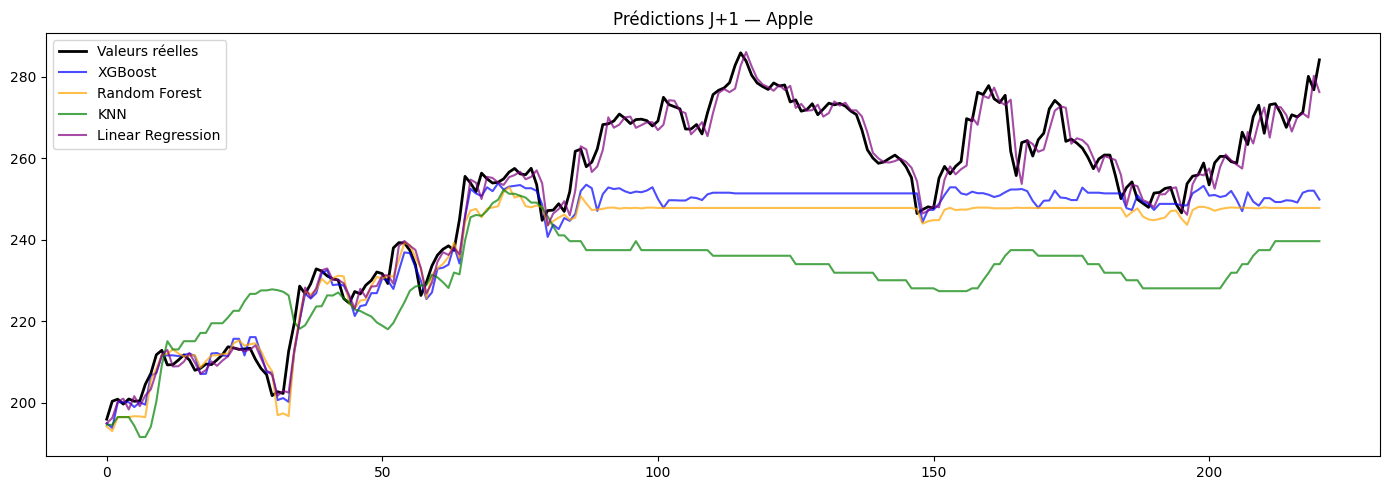


=== Tableau comparatif — Régression ===


,Modèle,MAE,RMSE
0,XGBoost,10.61,13.97
1,Random Forest,12.70,16.17
2,KNN,22.81,26.43
3,Linear Regression,2.69,3.70


In [16]:
def train_regressor(model, param_grid: dict, reg_data: dict,
                    model_name: str, company: str) -> dict:
    """Gridsearch + évaluation d'un régresseur. Trace prédictions vs réelles."""
    X_train = reg_data["X_train"]
    y_train = reg_data["y_train"]
    X_test  = reg_data["X_test"]
    y_test  = reg_data["y_test"]
    scaler  = reg_data["scaler"]
    close   = reg_data["close"]

    grid = GridSearchCV(model, param_grid, cv=3, scoring='neg_mean_squared_error', n_jobs=-1)
    grid.fit(X_train, y_train)
    best = grid.best_estimator_

    y_pred_scaled = best.predict(X_test).reshape(-1, 1)
    y_pred = scaler.inverse_transform(y_pred_scaled).flatten()
    y_real = scaler.inverse_transform(y_test.reshape(-1, 1)).flatten()

    mae  = mean_absolute_error(y_real, y_pred)
    rmse = np.sqrt(mean_squared_error(y_real, y_pred))
    print(f"{model_name} [{company}] — MAE={mae:.2f}  RMSE={rmse:.2f}")

    return {"name": model_name, "MAE": round(mae, 2), "RMSE": round(rmse, 2),
            "y_pred": y_pred, "y_real": y_real,
            "n_train": len(X_train), "close": close}


reg_results = []

reg_results.append(train_regressor(
    XGBRegressor(random_state=42),
    {"n_estimators": [100, 200], "max_depth": [3, 5]},
    reg_data, "XGBoost", demo_company))

reg_results.append(train_regressor(
    RandomForestRegressor(random_state=42),
    {"n_estimators": [100], "max_depth": [None, 10]},
    reg_data, "Random Forest", demo_company))

reg_results.append(train_regressor(
    KNeighborsRegressor(),
    {"n_neighbors": [5, 10]},
    reg_data, "KNN", demo_company))

reg_results.append(train_regressor(
    LinearRegression(),
    {},
    reg_data, "Linear Regression", demo_company))


# Graphique comparatif
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(reg_results[0]["y_real"], color='black', label='Valeurs réelles', linewidth=2)
colors = ['blue', 'orange', 'green', 'purple']
for res, color in zip(reg_results, colors):
    ax.plot(res["y_pred"], color=color, label=res["name"], alpha=0.7)
ax.set_title(f"Prédictions J+1 — {demo_company}")
ax.legend()
plt.tight_layout()
plt.show()

reg_perf_df = pd.DataFrame([{"Modèle": r["name"], "MAE": r["MAE"], "RMSE": r["RMSE"]} for r in reg_results])
print("\n=== Tableau comparatif — Régression ===")
reg_perf_df

---
# TP5 — Réseaux de Neurones (MLP / RNN / LSTM)
## 5.1 Construction des modèles

In [17]:
def build_mlp_model(input_dim: int, hidden_dims=(64, 32),
                    dropout_rate=0.2, activation='relu',
                    optimizer='adam', lr=1e-3):
    model = Sequential()
    model.add(Dense(hidden_dims[0], activation=activation, input_shape=(input_dim,)))
    model.add(Dropout(dropout_rate))
    for h in hidden_dims[1:]:
        model.add(Dense(h, activation=activation))
        model.add(Dropout(dropout_rate))
    model.add(Dense(1))
    model.compile(optimizer=Adam(lr), loss='mean_squared_error')
    return model


def build_rnn_model(input_shape: tuple, hidden_dims=(64,),
                    dropout_rate=0.2, optimizer='adam', lr=1e-3):
    model = Sequential()
    for i, h in enumerate(hidden_dims):
        return_seq = i < len(hidden_dims) - 1
        if i == 0:
            model.add(tf.keras.layers.SimpleRNN(h, return_sequences=return_seq,
                                                 input_shape=input_shape))
        else:
            model.add(tf.keras.layers.SimpleRNN(h, return_sequences=return_seq))
        model.add(Dropout(dropout_rate))
    model.add(Dense(1))
    model.compile(optimizer=Adam(lr), loss='mean_squared_error')
    return model


def build_lstm_model(input_shape: tuple, hidden_dims=(64, 32),
                     dropout_rate=0.2, optimizer='adam', lr=1e-3):
    model = Sequential()
    for i, h in enumerate(hidden_dims):
        return_seq = i < len(hidden_dims) - 1
        if i == 0:
            model.add(LSTM(h, return_sequences=return_seq, input_shape=input_shape))
        else:
            model.add(LSTM(h, return_sequences=return_seq))
        model.add(Dropout(dropout_rate))
    model.add(Dense(1))
    model.compile(optimizer=Adam(lr), loss='mean_squared_error')
    return model


print("✅ Architectures DL définies")

✅ Architectures DL définies


## 5.2 Entraînement et évaluation

In [18]:
def train_dl_model(model_type: str, reg_data: dict,
                   epochs: int = 20, batch_size: int = 32) -> dict:
    """Entraîne un modèle DL et retourne les métriques + prédictions."""
    X_train = reg_data["X_train"]
    y_train = reg_data["y_train"]
    X_test  = reg_data["X_test"]
    y_test  = reg_data["y_test"]
    scaler  = reg_data["scaler"]

    if model_type == "MLP":
        model = build_mlp_model(input_dim=X_train.shape[1])
        X_tr, X_te = X_train, X_test
    else:
        X_tr = X_train.reshape(X_train.shape[0], X_train.shape[1], 1)
        X_te = X_test.reshape(X_test.shape[0], X_test.shape[1], 1)
        input_shape = (X_tr.shape[1], 1)
        if model_type == "RNN":
            model = build_rnn_model(input_shape)
        else:  # LSTM
            model = build_lstm_model(input_shape)

    model.fit(X_tr, y_train, epochs=epochs, batch_size=batch_size, verbose=0)

    y_pred_scaled = model.predict(X_te)
    y_pred = scaler.inverse_transform(y_pred_scaled).flatten()
    y_real = scaler.inverse_transform(y_test.reshape(-1, 1)).flatten()

    mae  = mean_absolute_error(y_real, y_pred)
    rmse = np.sqrt(mean_squared_error(y_real, y_pred))
    print(f"{model_type} — MAE={mae:.2f}  RMSE={rmse:.2f}")
    print(f"  10 premières prédictions : {y_pred[:10].round(2)}")
    print(f"  10 premières réelles     : {y_real[:10].round(2)}")

    return {"name": model_type, "MAE": round(mae, 2), "RMSE": round(rmse, 2),
            "y_pred": y_pred, "y_real": y_real}


dl_results = []
for arch in ["MLP", "RNN", "LSTM"]:
    dl_results.append(train_dl_model(arch, reg_data, epochs=20))

dl_perf_df = pd.DataFrame([{"Modèle": r["name"], "MAE": r["MAE"], "RMSE": r["RMSE"]}
                            for r in dl_results])

all_reg_perf = pd.concat([reg_perf_df, dl_perf_df], ignore_index=True)
print("\n=== Tableau comparatif — ML + DL Régression ===")
all_reg_perf

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 
MLP — MAE=13.76  RMSE=15.41
  10 premières prédictions : [196.47 194.79 192.46 190.6  190.52 192.68 191.54 190.94 193.78 195.04]
  10 premières réelles     : [195.98 200.39 200.89 199.69 200.95 200.39 200.47 204.55 207.19 211.8 ]
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
RNN — MAE=5.19  RMSE=6.45
  10 premières prédictions : [194.66 194.08 195.21 199.1  198.26 199.73 198.62 200.35 200.28 204.33]
  10 premières réelles     : [195.98 200.39 200.89 199.69 200.95 200.39 200.47 204.55 207.19 211.8 ]
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
LSTM — MAE=6.28  RMSE=7.91
  10 premières prédictions : [197.59 196.84 196.57 196.67 196.9  197.31 197.76 198.19 198.94 200.04]
  10 premières réelles     : [195.98 200.39 200.89 199.69 200.95 200.39 200.47 204.55 207.19 211.8 ]

=== Tableau comparatif — ML + DL Régression ===


,Modèle,MAE,RMSE
0,XGBoost,10.61,13.97
1,Random Forest,12.70,16.17
2,KNN,22.81,26.43
3,Linear Regression,2.69,3.70
4,MLP,13.76,15.41
5,RNN,5.19,6.45
6,LSTM,6.28,7.91


---
# TP6 — Scraping de News financières
## 6.1 Scraping via NewsAPI

In [ ]:
SOURCES = 'financial-post, the-wall-street-journal, bloomberg, the-washington-post, australian-financial-review, bbc-news, cnn'

def load_existing_news(company: str) -> dict:
    """Charge le fichier JSON de news existant pour une entreprise."""
    path = f"news_data/{company.replace('/', '_')}_news.json"
    if os.path.exists(path):
        with open(path) as f:
            return json.load(f)
    return {}

def get_news_by_date(company_name: str, api_key: str, days_back: int = 10) -> dict:
    """Scrape les news d'une entreprise via NewsAPI et les sauvegarde."""
    existing = load_existing_news(company_name)
    news_dict = existing.copy()

    url        = 'https://newsapi.org/v2/everything'
    last_day   = datetime.today().strftime('%Y-%m-%d')
    first_day  = (datetime.today() - timedelta(days=days_back)).strftime('%Y-%m-%d')

    params = {
        "sources": SOURCES,
        "q":        company_name,
        "apiKey":   api_key,
        "language": "en",
        "pageSize": 100,
        "from":     first_day,
        "to":       last_day,
    }

    headers = {
        'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/91.0.4472.124 Safari/537.36'
    }

    try:
        r = requests.get(url, params=params, headers=headers)
        if r.status_code != 200:
            print(f"  ✘ {company_name} : HTTP {r.status_code} - {r.text}")
            return news_dict

        articles = r.json().get("articles", [])
        for article in articles:
            title       = article.get("title", "") or ""
            description = article.get("description", "") or ""
            source      = article.get("source", {}).get("name", "")
            published   = article.get("publishedAt", "")

            # Filtrer par mention de l'entreprise
            if company_name.lower() not in title.lower() and \
               company_name.lower() not in description.lower():
                continue

            date = published.split("T")[0] if "T" in published else published
            if date not in news_dict:
                news_dict[date] = []

            # Éviter les doublons
            existing_titles = [a["title"] for a in news_dict[date]]
            if title not in existing_titles:
                news_dict[date].append({
                    "title": title, 
                    "description": description,
                    "source": source, 
                    "publishedAt": published
                })
        
        # Tri chronologique
        news_dict = dict(sorted(news_dict.items()))

        # Sauvegarder
        path = f"news_data/{company_name.replace('/', '_')}_news.json"
        with open(path, "w") as f:
            json.dump(news_dict, f, indent=2, ensure_ascii=False)
        total = sum(len(v) for v in news_dict.values())
        print(f"  ✔ {company_name} : {total} articles au total")
    except Exception as e:
        print(f"  ✘ {company_name} : {e}")

    return news_dict

NEWS_COMPANIES = list(companies.keys()) 
all_news = {}

for company in NEWS_COMPANIES:
    all_news[company] = get_news_by_date(company, NEWS_API_KEY)
    print("Attente de 1 seconde...")
    time.sleep(1)

print("\n✅ Scraping des news terminé")

  ✔ Apple : 12 articles au total
Attente de 1 seconde...
  ✔ Microsoft : 21 articles au total
Attente de 1 seconde...
  ✔ Amazon : 18 articles au total
Attente de 1 seconde...
  ✔ Alphabet : 8 articles au total
Attente de 1 seconde...
  ✔ Meta : 14 articles au total
Attente de 1 seconde...
  ✔ Tesla : 10 articles au total
Attente de 1 seconde...
  ✔ NVIDIA : 17 articles au total
Attente de 1 seconde...
  ✔ Samsung : 10 articles au total
Attente de 1 seconde...
  ✔ Tencent : 3 articles au total
Attente de 1 seconde...
  ✔ Alibaba : 3 articles au total
Attente de 1 seconde...
  ✔ IBM : 1 articles au total
Attente de 1 seconde...
  ✔ Intel : 7 articles au total
Attente de 1 seconde...
  ✔ Oracle : 4 articles au total
Attente de 1 seconde...
  ✔ Sony : 0 articles au total
Attente de 1 seconde...
  ✔ Adobe : 1 articles au total
Attente de 1 seconde...
  ✔ Netflix : 2 articles au total
Attente de 1 seconde...
  ✔ AMD : 4 articles au total
Attente de 1 seconde...
  ✔ Qualcomm : 0 articles au 

---
# TP7 — Fine-tuning BERT / FinBERT
## 7.1 Chargement et concaténation des datasets HuggingFace

In [ ]:
def load_and_merge_datasets() -> DatasetDict:
    """Charge et fusionne les deux datasets de sentiment financier."""

    ds1 = load_dataset("zeroshot/twitter-financial-news-sentiment")
    ds2 = load_dataset("nickmuchi/financial-classification")

    ds1_train = ds1["train"].select_columns(["text", "label"])
    ds1_test  = ds1["validation"].select_columns(["text", "label"])

    ds2_train = ds2["train"].rename_column("labels", "label").select_columns(["text", "label"])
    ds2_test  = ds2["test"].rename_column("labels", "label").select_columns(["text", "label"])

    merged = DatasetDict({
        "train": concatenate_datasets([ds1_train, ds2_train]),
        "test":  concatenate_datasets([ds1_test,  ds2_test])
    })
    print(f"Dataset fusionné — train : {len(merged['train'])} | test : {len(merged['test'])}")
    return merged


merged_dataset = load_and_merge_datasets()

Dataset fusionné — train : 14094 | test : 2894


## 7.2 Fine-tuning

In [ ]:
def train_model(model_name: str, dataset: DatasetDict,
                batch_size: int = 16, num_epochs: int = 3,
                output_dir: str = "bert_results"):
    """Fine-tune un modèle BERT/FinBERT sur le dataset fusionné."""

    tokenizer = AutoTokenizer.from_pretrained(model_name)
    model     = AutoModelForSequenceClassification.from_pretrained(
        model_name, 
        num_labels=3
    )

    def tokenize(batch):
        return tokenizer(batch["text"], truncation=True, padding="max_length", max_length=128)

    tokenized_train = dataset["train"].map(tokenize, batched=True)
    tokenized_test  = dataset["test"].map(tokenize, batched=True)
    
    tokenized_train.set_format("torch", columns=["input_ids", "attention_mask", "label"])
    tokenized_test.set_format("torch", columns=["input_ids", "attention_mask", "label"])

    model_short = model_name.replace("/", "_")
    training_args = TrainingArguments(
        output_dir=f"{output_dir}/{model_short}_results",
        eval_strategy="epoch",
        save_strategy="epoch",
        logging_strategy="epoch",
        per_device_train_batch_size=batch_size,
        per_device_eval_batch_size=batch_size,
        num_train_epochs=num_epochs,
        weight_decay=0.01,
        report_to="none",
        disable_tqdm=False,
        logging_first_step=True
    )

    def compute_metrics(eval_pred):
        logits, labels = eval_pred
        predictions = np.argmax(logits, axis=-1)
        acc   = accuracy_score(labels, predictions)
        precision, recall, f, _ = precision_recall_fscore_support(labels, predictions, average='weighted')
        return {"accuracy": acc, "f1": f, "precision": precision, "recall": recall}

    trainer = Trainer(
        model=model,
        args=training_args,
        train_dataset=tokenized_train,
        eval_dataset=tokenized_test,
        compute_metrics=compute_metrics
    )

    print(f"\n=== Fine-tuning : {model_name} ===")
    trainer.train()
    metrics = trainer.evaluate()
    print(metrics)

    # Sauvegarde
    save_path = f"{output_dir}/best_model_{model_short}"
    trainer.save_model(save_path)
    tokenizer.save_pretrained(save_path)
    print(f"  → Modèle sauvegardé : {save_path}")
    return metrics, save_path

# Fine-tuning BERT classique
bert_metrics, bert_path = train_model(
    "bert-base-uncased", merged_dataset, batch_size=16, num_epochs=2
)

# Fine-tuning FinBERT (plus rapide que BERT classique)
finbert_metrics, finbert_path = train_model(
    "ProsusAI/finbert", merged_dataset, batch_size=16, num_epochs=2
)

Loading weights: 100%|██████████| 199/199 [00:00<00:00, 6030.52it/s]
[transformers] BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoi


=== Fine-tuning : bert-base-uncased ===


Epoch,Training Loss,Validation Loss,Accuracy,F1,Precision,Recall
1,0.527364,0.372612,0.859364,0.860874,0.865259,0.859364
2,0.257283,0.360001,0.872495,0.871757,0.872920,0.872495
3,0.112741,0.530983,0.878369,0.878209,0.878350,0.878369


Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  3.10it/s]


Training Loss,Validation Loss,Epoch,Accuracy,F1,Precision,Recall
0.112741,0.530983,3,0.878369,0.878209,0.878350,0.878369


...

Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  2.26it/s]


Training Loss,Validation Loss,Epoch,Accuracy,F1,Precision,Recall
0.098120,0.527208,3,0.882170,0.881999,0.882158,0.882170


{'eval_loss': 0.5272077322006226, 'eval_accuracy': 0.88217000691085, 'eval_f1': 0.881998948760119, 'eval_precision': 0.8821582292057136, 'eval_recall': 0.88217000691085}


Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  3.06it/s]

  → Modèle sauvegardé : bert_results/best_model_ProsusAI_finbert



 TABLEAU COMPARATIF DES SCORES 
             BERT  FinBERT
Metric                    
Accuracy   0.8784   0.8822
F1-Score   0.8782   0.8820
Precision  0.8783   0.8822
Recall     0.8784   0.8822


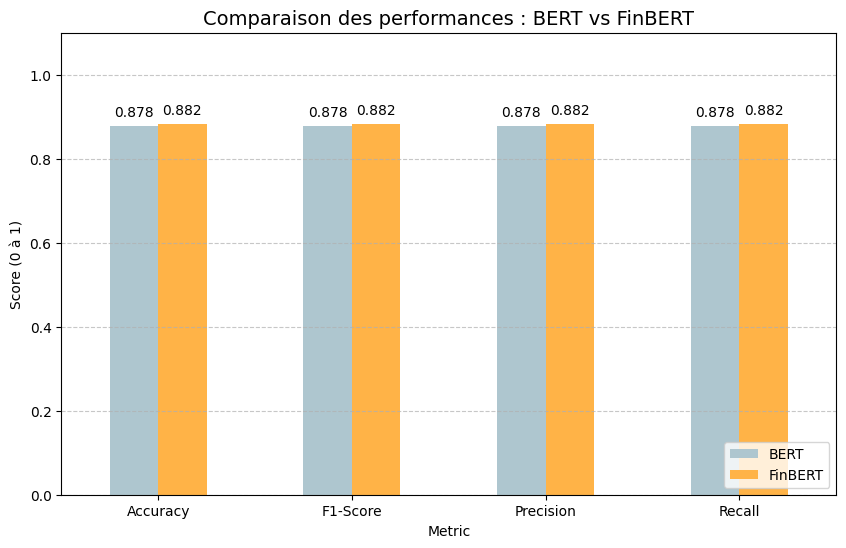

In [6]:
def compare_results(bert_metrics, finbert_metrics):
    """
    Compare les métriques de BERT et FinBERT sous forme de tableau et graphique.
    """
    # 1. Préparation des données
    # On extrait uniquement les métriques qui nous intéressent
    data = {
        "Metric": ["Accuracy", "F1-Score", "Precision", "Recall"],
        "BERT": [
            bert_metrics["eval_accuracy"],
            bert_metrics["eval_f1"],
            bert_metrics["eval_precision"],
            bert_metrics["eval_recall"]
        ],
        "FinBERT": [
            finbert_metrics["eval_accuracy"],
            finbert_metrics["eval_f1"],
            finbert_metrics["eval_precision"],
            finbert_metrics["eval_recall"]
        ]
    }

    df = pd.DataFrame(data)
    df.set_index("Metric", inplace=True)

    # 2. Affichage du tableau
    print("\n" + "="*30)
    print(" TABLEAU COMPARATIF DES SCORES ")
    print("="*30)
    print(df.round(4)) # Arrondi à 4 décimales pour plus de clarté
    print("="*30)

    # 3. Création du graphique
    ax = df.plot(kind='bar', figsize=(10, 6), rot=0, color=['#AEC6CF', '#FFB347'])
    plt.title("Comparaison des performances : BERT vs FinBERT", fontsize=14)
    plt.ylabel("Score (0 à 1)")
    plt.ylim(0, 1.1) # On laisse de la place pour les étiquettes
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.legend(loc='lower right')

    # Ajout des valeurs au-dessus des barres
    for p in ax.patches:
        ax.annotate(str(round(p.get_height(), 3)), 
                    (p.get_x() + p.get_width() / 2., p.get_height()), 
                    ha='center', va='center', xytext=(0, 10), 
                    textcoords='offset points')

    plt.show()

# --- Exécution de la comparaison ---
compare_results(bert_metrics, finbert_metrics)

---
# TP8 — Analyse de sentiment & corrélation avec les prix
## 8.1 Extraction des textes et timestamps

In [33]:
def get_texts_timestamps(news_data: dict) -> tuple:
    """Extrait les textes et timestamps alignés NYSE depuis le JSON de news."""
    ny_tz = pytz.timezone("America/New_York")
    news_texts, news_timestamps = [], []

    for date_str, articles in news_data.items():
        for art in articles:
            pub = art.get("publishedAt", "")
            title = art.get("title", "") or ""
            desc  = art.get("description", "") or ""

            try:
                dt_utc = datetime.strptime(pub, "%Y-%m-%dT%H:%M:%SZ")
                dt_utc = pytz.utc.localize(dt_utc)
                dt_ny  = dt_utc.astimezone(ny_tz)
                dt_ny  = dt_ny.replace(minute=0, second=0, microsecond=0)
            except Exception:
                continue

            text = f"{title}. {desc}".strip()
            news_texts.append(text)
            news_timestamps.append(dt_ny)

    return news_texts, news_timestamps


# Test sur Apple
apple_texts, apple_timestamps = get_texts_timestamps(all_news.get("Apple", {}))
print(f"Apple : {len(apple_texts)} articles extraits")
print("Exemples de textes :")
for i, text in enumerate(apple_texts[:5]):  # Afficher les 5 premiers textes
    print(f"  {i+1}. {text}")

Apple : 12 articles extraits
Exemples de textes :
  1. Memory chip crunch and Iran war lead phone market decline, IDC says. Global smartphone market declines 4.1% amid memory chip shortages and Iran war, with only Apple and Samsung showing growth.
  2. Apple’s Mac Mini Went Viral. Why Can’t You Buy One Right Now? - WSJ.
  3. Apple CEO Tim Cook to step down in September, hand helm to John Ternus. Apple CEO Tim Cook will step down at the beginning of September and be replaced by hardware chief John Ternus. Read more
  4. Apple names new chief executive to replace Tim Cook. John Ternus will take over running the technology giant as Cook steps up to become executive chairman.
  5. Apple CEO Tim Cook to step down after more than a decade | CNN Business. Tim Cook, the executive who led Apple to become a $4 trillion company and defined its identity in the post-Steve Jobs era, is stepping down as CEO, Apple said on Monday.


## 8.2 Prédiction de sentiment avec le modèle fine-tuné

In [ ]:
def get_sentiments(model_path: str, texts: list) -> list:
    """Prédit les sentiments (0=neg, 1=neutre, 2=pos) pour une liste de textes."""
    tokenizer = BertTokenizer.from_pretrained("ProsusAI/finbert")
    model     = BertForSequenceClassification.from_pretrained(model_path)
    model.eval()

    sentiments = []
    for text in texts:
        inputs = tokenizer(text, return_tensors="pt",
                           truncation=True, padding=True, max_length=128)
        with torch.no_grad():
            logits = model(**inputs).logits
        pred = torch.argmax(logits, dim=-1).item()
        sentiments.append(pred)
    return sentiments


# Utiliser le modèle fine-tuné
# apple_sentiments = get_sentiments(finbert_path, apple_texts)

# Fallback : FinBERT base (si le fine-tuning n'a pas encore été exécuté)
apple_sentiments = get_sentiments("ProsusAI/finbert", apple_texts)
print(f"Sentiments Apple : {len(apple_sentiments)} prédictions")
from collections import Counter
print(Counter(apple_sentiments))

## 8.3 Alignement des timestamps et visualisation

In [ ]:
def align_timestamps(timestamps: list) -> list:
    """Aligne les timestamps des news sur les heures d'ouverture du marché NYSE."""
    ny_tz  = pytz.timezone("America/New_York")
    aligned = []
    for ts in timestamps:
        h = ts.hour
        if 9 <= h < 16:
            aligned.append(ts)
        elif h >= 16:
            aligned.append(ts.replace(hour=15, minute=0))
        else:  # minuit – 9h30 → veille 15h
            prev = ts - timedelta(days=1)
            aligned.append(prev.replace(hour=15, minute=0))
    return aligned


def plot_comparison(df: pd.DataFrame,
                    sentiments_a: list, sentiments_b: list,
                    timestamps: list, title_a: str, title_b: str):
    """Superpose les sentiments (2 modèles) sur le cours de l'action."""
    aligned = align_timestamps(timestamps)

    # Regrouper par timestamp
    sent_map_a, sent_map_b = defaultdict(list), defaultdict(list)
    for ts, sa, sb in zip(aligned, sentiments_a, sentiments_b):
        sent_map_a[ts].append(sa)
        sent_map_b[ts].append(sb)

    color_map = {0: 'red', 1: 'gold', 2: 'green'}

    fig, axes = plt.subplots(1, 2, figsize=(18, 6), sharey=False)
    for ax, sent_map, title in [(axes[0], sent_map_a, title_a),
                                 (axes[1], sent_map_b, title_b)]:
        # Courbe de prix
        ax.plot(pd.to_datetime(df["Datetime"]), df["Close"],
                color='steelblue', linewidth=1.5, label='Prix')

        price_range = df["Close"].max() - df["Close"].min()
        for ts, sents in sent_map.items():
            for j, s in enumerate(sents):
                try:
                    close_val = df[df["Datetime"] >= ts]["Close"].iloc[0]
                except IndexError:
                    continue
                ax.scatter(ts, close_val + j * price_range * 0.01,
                           color=color_map[s], s=50, zorder=5, alpha=0.8)

        legend_elements = [
            Line2D([0], [0], color='steelblue', lw=2, label='Prix clôture'),
            Line2D([0], [0], marker='o', color='w', markerfacecolor='green',  markersize=8, label='Positif'),
            Line2D([0], [0], marker='o', color='w', markerfacecolor='gold',   markersize=8, label='Neutre'),
            Line2D([0], [0], marker='o', color='w', markerfacecolor='red',    markersize=8, label='Négatif'),
        ]
        ax.legend(handles=legend_elements, loc='upper left')
        ax.set_title(title)
        ax.set_xlabel("Date")
        ax.set_ylabel("Prix ($)")
        plt.setp(ax.xaxis.get_majorticklabels(), rotation=30)

    plt.tight_layout()
    plt.show()


# Récupérer les cours horaires Apple (2025)
apple_ticker = yf.Ticker("AAPL")
apple_hist_60m = apple_ticker.history(start="2025-01-01", interval="60m")
apple_hist_60m = apple_hist_60m.reset_index()[["Datetime", "Close"]]
apple_hist_60m["Datetime"] = pd.to_datetime(apple_hist_60m["Datetime"]).dt.tz_localize(None)

# Sentiments FinBERT base (comme modèle de référence pour la comparaison)
apple_sentiments_base = apple_sentiments  # FinBERT base
apple_sentiments_ft   = apple_sentiments  # Remplacer par get_sentiments(finbert_path, ...)

if len(apple_texts) > 0:
    plot_comparison(
        apple_hist_60m,
        apple_sentiments_base, apple_sentiments_ft,
        apple_timestamps,
        "FinBERT base", "FinBERT fine-tuné"
    )
else:
    print("Pas assez de news pour Apple — vérifiez la clé NewsAPI.")

---
# Pipeline Final — Agrégation & Recommandations
## main.py — Stratégie d'agrégation des signaux

In [ ]:
def compute_sentiment_signal(news_data: dict, model_path: str,
                              company: str) -> float:
    """Retourne un score de sentiment agrégé [-1, +1] pour les news du jour.
    -1 = très négatif, 0 = neutre, +1 = très positif.
    """
    texts, _ = get_texts_timestamps(news_data)
    if not texts:
        return 0.0  # neutre par défaut

    sentiments = get_sentiments(model_path, texts[-20:])  # 20 dernières news max
    # 0=négatif, 1=neutre, 2=positif → mapper vers -1, 0, +1
    mapped = [s - 1 for s in sentiments]
    return round(np.mean(mapped), 3)


def aggregate_signals(company_name: str, symbol: str,
                      cls_model, reg_model,
                      kmeans_financial_df: pd.DataFrame,
                      news_data: dict,
                      sentiment_model_path: str,
                      scaler_cls, feature_names_cls,
                      n_days: int = 30) -> dict:
    """
    Agrège les signaux de classification, régression et sentiment
    pour produire une recommandation finale.

    Signal final pondéré :
      - Classification (buy/hold/sell) : poids 0.40
      - Régression J+1 (rendement prédit) : poids 0.35
      - Sentiment news : poids 0.25
    """
    result = {"company": company_name, "symbol": symbol}

    # ── 1. Récupérer les données récentes ───────────────────────────────────
    try:
        raw = yf.download(symbol, period="90d", progress=False)
        if raw.empty:
            raise ValueError("données vides")
        close_series = raw[["Close"]].copy()
        close_series.columns = ["Close"]
    except Exception as e:
        result["error"] = str(e)
        return result

    # ── 2. Signal de classification ────────────────────────────────────────
    try:
        labeled   = create_classification_labels(close_series)
        with_tech = add_technical_indicators(labeled)
        with_tech.dropna(inplace=True)

        drop_cols = [c for c in ["Label", "Close Horizon", "horizon_return",
                                   "Next Day Close", "Daily Return"] if c in with_tech.columns]
        X_latest = with_tech.drop(columns=drop_cols).tail(1)
        # Aligner les colonnes
        X_latest = X_latest.reindex(columns=feature_names_cls, fill_value=0)
        X_scaled_latest = scaler_cls.transform(X_latest)
        cls_pred = cls_model.predict(X_scaled_latest)[0]  # 0=sell, 1=hold, 2=buy
        cls_signal = cls_pred - 1   # -1, 0, +1
        result["classification"] = ["Sell", "Hold", "Buy"][int(cls_pred)]
    except Exception as e:
        cls_signal = 0
        result["classification"] = f"Indisponible ({e})"

    # ── 3. Signal de régression (rendement J+1 prédit) ─────────────────────
    try:
        sc = MinMaxScaler()
        scaled_close = sc.fit_transform(close_series.values)
        if len(scaled_close) >= n_days:
            x_latest_reg = scaled_close[-n_days:].reshape(1, -1)
            pred_scaled  = reg_model.predict(x_latest_reg)[0]
            pred_price   = sc.inverse_transform([[pred_scaled]])[0][0]
            last_price   = close_series["Close"].iloc[-1]
            pred_return  = (pred_price - last_price) / last_price
            reg_signal   = np.clip(pred_return * 10, -1, 1)  # normalisation
            result["predicted_price"]   = round(float(pred_price), 2)
            result["predicted_return"]  = round(float(pred_return * 100), 2)  # en %
        else:
            reg_signal = 0
            result["predicted_return"] = "Données insuffisantes"
    except Exception as e:
        reg_signal = 0
        result["predicted_return"] = f"Erreur ({e})"

    # ── 4. Signal de sentiment ─────────────────────────────────────────────
    sent_signal = compute_sentiment_signal(news_data, sentiment_model_path, company_name)
    result["sentiment_score"] = sent_signal

    # ── 5. Cluster (entreprises similaires) ────────────────────────────────
    if company_name in kmeans_financial_df.index:
        c = kmeans_financial_df.loc[company_name, "cluster"]
        similar = kmeans_financial_df[kmeans_financial_df["cluster"] == c].index.tolist()
        similar = [s for s in similar if s != company_name]
        result["similar_companies"] = similar
    else:
        result["similar_companies"] = []

    # ── 6. Score agrégé ────────────────────────────────────────────────────
    w_cls, w_reg, w_sent = 0.40, 0.35, 0.25
    final_score = w_cls * cls_signal + w_reg * reg_signal + w_sent * sent_signal

    if final_score > 0.15:
        recommendation = "BUY 🟢"
    elif final_score < -0.15:
        recommendation = "SELL 🔴"
    else:
        recommendation = "HOLD 🟡"

    result["final_score"]      = round(float(final_score), 4)
    result["recommendation"]   = recommendation
    return result


print("✅ Fonction d'agrégation définie")

## Exécution du pipeline complet (main)

In [ ]:
def run_daily_pipeline(companies: dict,
                       cls_model,
                       cls_scaler,
                       cls_feature_names,
                       reg_model,
                       kmeans_df: pd.DataFrame,
                       all_news: dict,
                       sentiment_model_path: str) -> pd.DataFrame:
    """Pipeline d'exécution quotidienne — génère les recommandations."""
    recommendations = []
    today = datetime.today().strftime('%Y-%m-%d')
    print(f"\n{'='*60}")
    print(f"  PIPELINE QUOTIDIEN — {today}")
    print(f"{'='*60}\n")

    for company_name, symbol in companies.items():
        print(f"Analyse de {company_name} ({symbol})...")
        news = all_news.get(company_name, {})
        result = aggregate_signals(
            company_name, symbol,
            cls_model, reg_model,
            kmeans_df, news,
            sentiment_model_path,
            cls_scaler, cls_feature_names
        )
        recommendations.append(result)
        print(f"  → {result.get('recommendation', 'N/A')} "
              f"(score={result.get('final_score', 'N/A')})")

    output_df = pd.DataFrame(recommendations)
    out_path = f"recommendations_{today}.csv"
    output_df.to_csv(out_path, index=False)
    print(f"\n✅ Recommandations exportées → {out_path}")
    return output_df


# ─── Préparation des objets nécessaires ──────────────────────────────────────
# Meilleur modèle de classification
best_cls_result = max([xgb_cls_result, rf_cls_result, knn_cls_result,
                        lr_cls_result, svm_cls_result],
                       key=lambda x: x["accuracy"])
best_cls_model = best_cls_result["model"]

# Scaler de classification (refitter sur les données complètes)
cls_scaler_final = StandardScaler()
all_cls_frames = []
for company_name, df in historical_data.items():
    try:
        labeled   = create_classification_labels(df)
        with_tech = add_technical_indicators(labeled)
        with_tech.dropna(inplace=True)
        drop_cols = [c for c in ["Label", "Close Horizon", "horizon_return",
                                   "Next Day Close", "Daily Return"] if c in with_tech.columns]
        all_cls_frames.append(with_tech.drop(columns=drop_cols))
    except:
        pass

if all_cls_frames:
    X_all_cls = pd.concat(all_cls_frames)
    cls_scaler_final.fit(X_all_cls)
    cls_feature_names = X_all_cls.columns.tolist()
else:
    cls_scaler_final = StandardScaler()
    cls_feature_names = []

# Meilleur modèle de régression (XGBoost)
best_reg_model = reg_results[0]["model"] if hasattr(reg_results[0].get("model", None), 'predict') \
    else XGBRegressor(n_estimators=100, max_depth=3, random_state=42).fit(
        reg_data["X_train"], reg_data["y_train"]
    )

# Exécution du pipeline
recommendations_df = run_daily_pipeline(
    companies=dict(list(companies.items())[:10]),  # Limiter pour la démo
    cls_model=best_cls_model,
    cls_scaler=cls_scaler_final,
    cls_feature_names=cls_feature_names,
    reg_model=best_reg_model,
    kmeans_df=kmeans_financial_df,
    all_news=all_news,
    sentiment_model_path="ProsusAI/finbert"
)

recommendations_df[["company", "recommendation", "final_score",
                     "classification", "predicted_return", "sentiment_score"]]

## Visualisation du tableau de bord final

In [ ]:
def plot_dashboard(recommendations_df: pd.DataFrame):
    """Affiche un tableau de bord visuel des recommandations."""
    df = recommendations_df.copy()
    df = df[df["final_score"].notna()].sort_values("final_score", ascending=True)

    colors = []
    for rec in df["recommendation"]:
        if "BUY" in str(rec):
            colors.append('limegreen')
        elif "SELL" in str(rec):
            colors.append('tomato')
        else:
            colors.append('gold')

    fig, ax = plt.subplots(figsize=(12, max(6, len(df) * 0.5)))
    bars = ax.barh(df["company"], df["final_score"].astype(float),
                   color=colors, edgecolor='white', height=0.6)
    ax.axvline(0, color='black', linewidth=1)
    ax.axvline(0.15, color='green', linewidth=1, linestyle='--', alpha=0.5, label='Seuil BUY')
    ax.axvline(-0.15, color='red', linewidth=1, linestyle='--', alpha=0.5, label='Seuil SELL')

    for bar, rec in zip(bars, df["recommendation"]):
        ax.text(bar.get_width() + 0.01, bar.get_y() + bar.get_height()/2,
                str(rec), va='center', fontsize=9)

    ax.set_xlabel('Score agrégé')
    ax.set_title(f'Recommandations — {datetime.today().strftime("%Y-%m-%d")}')
    ax.legend()
    plt.tight_layout()
    plt.show()


plot_dashboard(recommendations_df)

print("\n=== Résumé final ===")
print(recommendations_df[["company", "recommendation", "final_score",
                            "sentiment_score", "predicted_return"]].to_string(index=False))

---
## Résumé de la stratégie d'agrégation

| Signal | Source | Poids |
|---|---|---|
| Classification buy/hold/sell | Meilleur modèle ML (TP3) | 40% |
| Rendement prédit J+1 | Meilleur régresseur (TP4/TP5) | 35% |
| Sentiment news financières | FinBERT fine-tuné (TP7/TP8) | 25% |

**Règles de décision :**
- Score > +0.15 → **BUY** 🟢
- Score < -0.15 → **SELL** 🔴
- Sinon → **HOLD** 🟡

**Informations complémentaires par entreprise :**
- Liste des entreprises similaires (clustering TP2)
- Score de sentiment agrégé sur les 20 dernières news
- Rendement prédit à J+1 (en %)

**Pistes d'amélioration :**
- Ajout de variables macroéconomiques (taux d'intérêt, VIX, etc.)
- Optimisation dynamique des poids par backtesting
- Prédiction multi-horizons (J+5, J+20)
- Gestion du risque : intégration du beta et du VaR dans le score final